In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

import _syntax_score_helper_function as ga
from _helper_functions import *

In [2]:
df=pd.read_csv('02-Supplemental-Tables/Supplemental-Table-2.tsv',sep='\t').set_index('Sequence')
df['Syntax Score']=df['Syntax Score'].apply(lambda fl: round(fl))
df.head()

,Sequence-id,Site Order,WT Activity,ABL Sequence,ABL Activity,Active Dependent on GATA+ETS,Syntax Score,Syntax Family Label
Sequence,,,,,,,,
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGGAAGTTTTCGAAGAGATAACA,ORL437027,L5-G3F-L1-E2F-L2-G2R-L4-E1F-L3-G1F-L6,0.829672,AAAATAGGCATCTGAAGCTCAAGCAAATTAAATATTTTGCTCACGC...,-0.345690,0,1,Moderate
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGGAAGTTTTCGAAGTTATCTCA,ORL437026,L5-G3F-L1-E2F-L2-G2R-L4-E1F-L3-G1R-L6,-0.931469,AAAATAGGCATCTGAAGCTCAAGCAAATTAAATATTTTGCTCACGC...,-1.442816,0,1,Moderate
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACTTCCGTTTTCGAAGAGATAACA,ORL437034,L5-G3F-L1-E2F-L2-G2R-L4-E1R-L3-G1F-L6,1.186847,AAAATAGGCATCTGAAGCTCAAGCAAATTAAATATTTTGCTCACTT...,-0.908347,1,8,Moderate
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACTTCCGTTTTCGAAGTTATCTCA,ORL437030,L5-G3F-L1-E2F-L2-G2R-L4-E1R-L3-G1R-L6,-0.547878,AAAATAGGCATCTGAAGCTCAAGCAAATTAAATATTTTGCTCACTT...,0.106554,0,1,Moderate
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCGAGATAACTTTCGAAACGGAAGTA,ORL433187,L5-G3F-L1-E2F-L2-G2R-L4-G1F-L3-E1F-L6,-0.476408,AAAATAGGCATCTGAAGCTCAAGCAAATTAAATATTTTGCTCGAAA...,-0.296820,0,0,Moderate


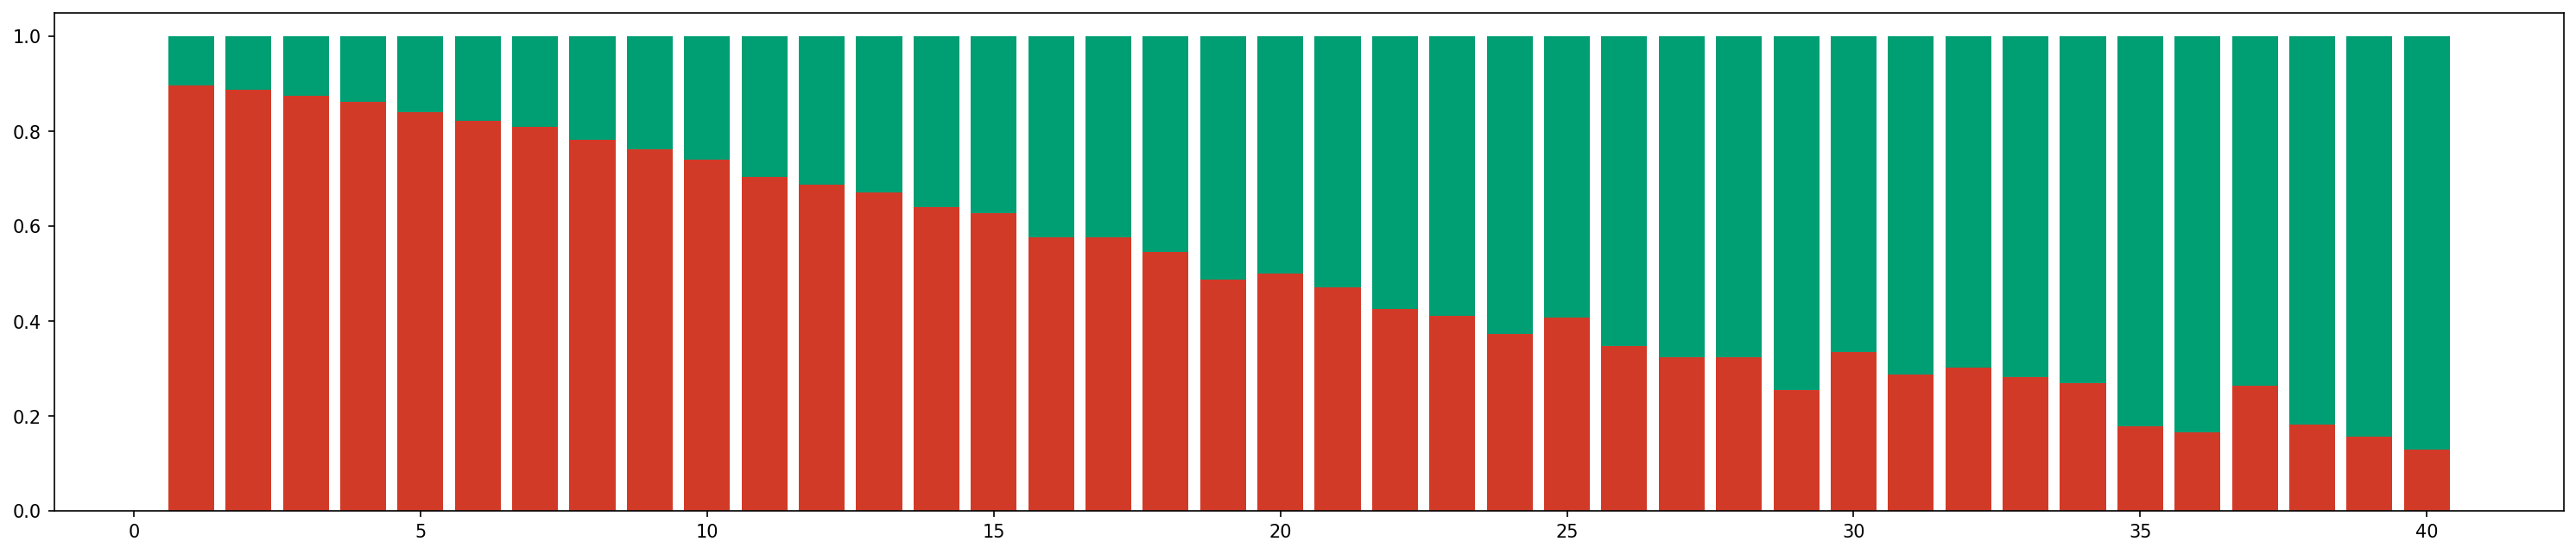

In [3]:
fig,ax=quickfig(25,5)

for i in range(1,40):
    actlist=df.loc[df['Syntax Score']==i,'WT Activity']
    abllist=df.loc[df['Syntax Score']==i,'ABL Activity']

    num_ens=0
    num_ine=0
    for wt,abl in zip(actlist,abllist):
        if wt=='N.D.' or abl=='N.D.': continue
        wt=float(wt)
        abl=float(abl)

        if wt>1 and abl<0: 
            num_ens+=1
        if wt <0:
            num_ine+=1

    if num_ine!=0:
        n=num_ens+num_ine
        ax.bar(x=i,height=num_ine/n,bottom=0,color=cb['orangenature'])
        ax.bar(x=i,height=num_ens /n,bottom=num_ine/n,color=cb['green'])
    else:
        ax.bar(x=i,height=1,color=cb['green'])


actlist=df.loc[df['Syntax Score']>40,'WT Activity']
abllist=df.loc[df['Syntax Score']>40,'ABL Activity']

num_ens=0
num_ine=0
for wt,abl in zip(actlist,abllist):
    if wt=='N.D.' or abl=='N.D.': continue
    wt=float(wt)
    abl=float(abl)

    if wt>1 and abl<0: 
        num_ens+=1
    if wt <0:
        num_ine+=1

if num_ine!=0:
    n=num_ens+num_ine
    ax.bar(x=i+1,height=num_ine/n,bottom=0,color=cb['orangenature'])
    ax.bar(x=i+1,height=num_ens/n,bottom=num_ine/n,color=cb['green'])
else:
    ax.bar(x=i,height=1,color=cb['green'])


